## Bonus: Error Analysis ##

### 0. Imports ###

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../src')
from preprocessing import build_preprocessor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    matthews_corrcoef, roc_auc_score, balanced_accuracy_score,
    f1_score, recall_score, precision_score, confusion_matrix,
    classification_report
)

%load_ext autoreload
%autoreload 2

/home/ioulios/DSIT/structural/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 1. Load Dataset ###

In [2]:
df = pd.read_csv('../data/heart.csv')
X = df.drop(columns='num')
y = df['num']

print(f"Dataset shape: {df.shape}")
print(f"Class distribution:\n{y.value_counts()}")

Dataset shape: (242, 14)
Class distribution:
num
0    131
1    111
Name: count, dtype: int64


### Dataset class Distribution ###

In [4]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"\nTrain class distribution:\n{y_train.value_counts()}")
print(f"\nValidation class distribution:\n{y_val.value_counts()}")

Train size: 193
Validation size: 49

Train class distribution:
num
0    104
1     89
Name: count, dtype: int64

Validation class distribution:
num
0    27
1    22
Name: count, dtype: int64


### Preprocessing ###

In [5]:
preprocessor = build_preprocessor()
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)

### Best model loading ###

In [6]:
best_params = {'shrinkage': 0.203, 'solver': 'lsqr'}
model = LinearDiscriminantAnalysis(**best_params)

### Model training, predictions and performance assesment ###

In [7]:
model.fit(X_train_proc, y_train)

y_pred = model.predict(X_val_proc)
y_prob = model.predict_proba(X_val_proc)[:, 1]


print(classification_report(y_val, y_pred))
print(f"MCC: {matthews_corrcoef(y_val, y_pred):.3f}")
print(f"AUC: {roc_auc_score(y_val, y_prob):.3f}")

              precision    recall  f1-score   support

           0       0.83      0.93      0.88        27
           1       0.89      0.77      0.83        22

    accuracy                           0.86        49
   macro avg       0.86      0.85      0.85        49
weighted avg       0.86      0.86      0.86        49

MCC: 0.713
AUC: 0.924


### Construction of the Confusion Matrix ###

In [9]:
# reset indices for clean alignment
X_val_reset = X_val.reset_index(drop=True)
y_val_reset  = y_val.reset_index(drop=True)
y_pred_series = pd.Series(y_pred, name='predicted')
y_prob_series = pd.Series(y_prob, name='probability')

# create results dataframe
results_df = X_val_reset.copy()
results_df['true']        = y_val_reset.values
results_df['predicted']   = y_pred
results_df['probability'] = y_prob

# label each patient
def error_type(row):
    if row['true'] == 1 and row['predicted'] == 1:
        return 'TP'
    elif row['true'] == 0 and row['predicted'] == 0:
        return 'TN'
    elif row['true'] == 0 and row['predicted'] == 1:
        return 'FP'
    else:
        return 'FN'

results_df['error_type'] = results_df.apply(error_type, axis=1)

print(results_df['error_type'].value_counts())

error_type
TN    25
TP    17
FN     5
FP     2
Name: count, dtype: int64


### Confusion Matrix Heatmap ###

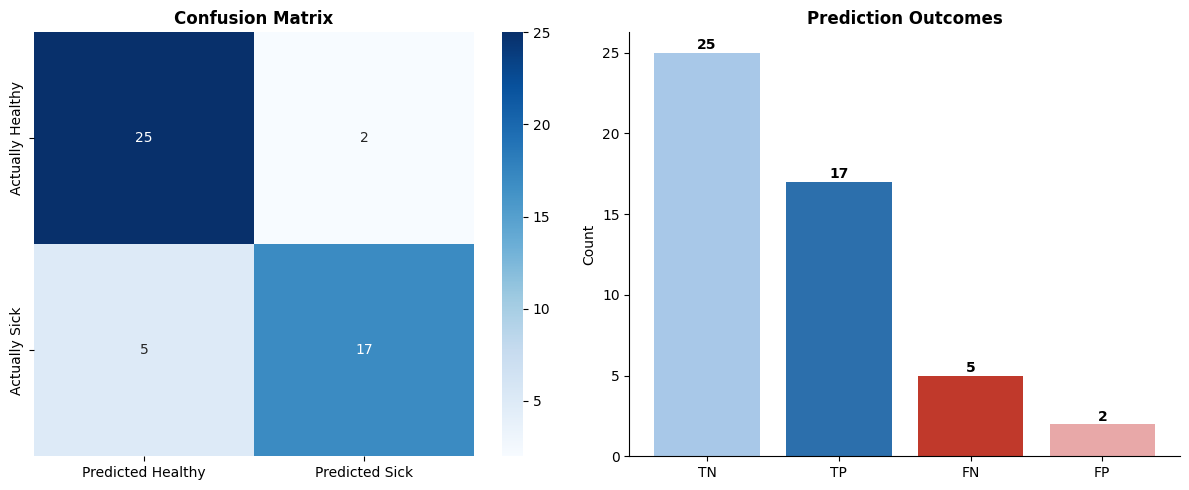

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# confusion matrix heatmap
cm = confusion_matrix(y_val_reset, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Healthy', 'Predicted Sick'],
            yticklabels=['Actually Healthy', 'Actually Sick'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontweight='bold')

# error type distribution
error_counts = results_df['error_type'].value_counts()
colors = {'TP': '#2C6FAC', 'TN': '#A8C8E8', 
          'FN': '#C0392B', 'FP': '#E8A8A8'}
axes[1].bar(error_counts.index, error_counts.values,
            color=[colors[e] for e in error_counts.index])
axes[1].set_title('Prediction Outcomes', fontweight='bold')
axes[1].set_ylabel('Count')
for i, (idx, val) in enumerate(error_counts.items()):
    axes[1].text(i, val + 0.2, str(val), ha='center', fontweight='bold')
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Age Distribution by prediction result ###

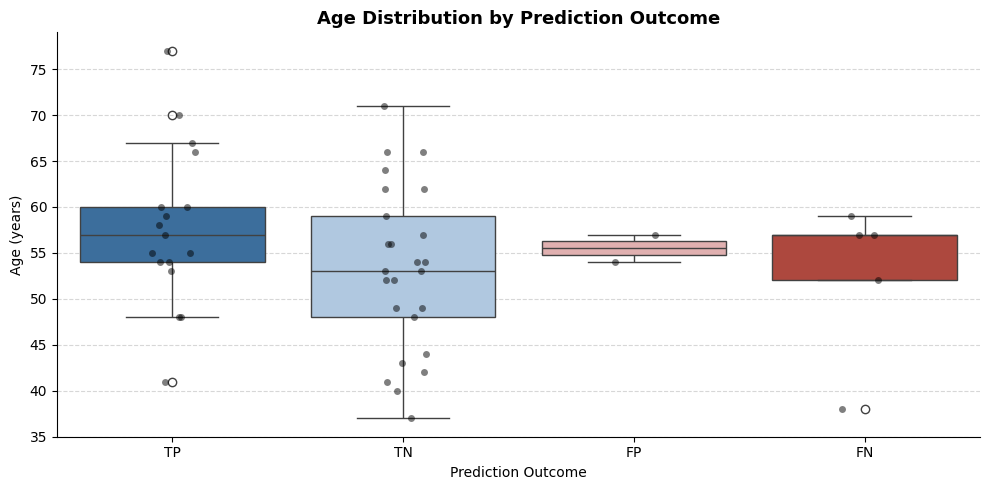


Age summary by error type:
            count  mean  std   min   25%   50%   75%   max
error_type                                                
FN            5.0  52.6  8.6  38.0  52.0  57.0  57.0  59.0
FP            2.0  55.5  2.1  54.0  54.8  55.5  56.2  57.0
TN           25.0  53.2  9.0  37.0  48.0  53.0  59.0  71.0
TP           17.0  57.8  8.7  41.0  54.0  57.0  60.0  77.0


In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

order = ['TP', 'TN', 'FP', 'FN']
colors = {'TP': '#2C6FAC', 'TN': '#A8C8E8',
          'FN': '#C0392B', 'FP': '#E8A8A8'}

sns.boxplot(data=results_df, x='error_type', y='age',
            order=order, palette=colors, ax=ax)
sns.stripplot(data=results_df, x='error_type', y='age',
              order=order, color='black', size=5, alpha=0.5, ax=ax)

ax.set_title('Age Distribution by Prediction Outcome', 
             fontweight='bold', fontsize=13)
ax.set_xlabel('Prediction Outcome')
ax.set_ylabel('Age (years)')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../figures/age_by_error_type.png', dpi=300, bbox_inches='tight')
plt.show()

# print summary statistics
print("\nAge summary by error type:")
print(results_df.groupby('error_type')['age'].describe().round(1))

### Other Features distributions by prediction result ###

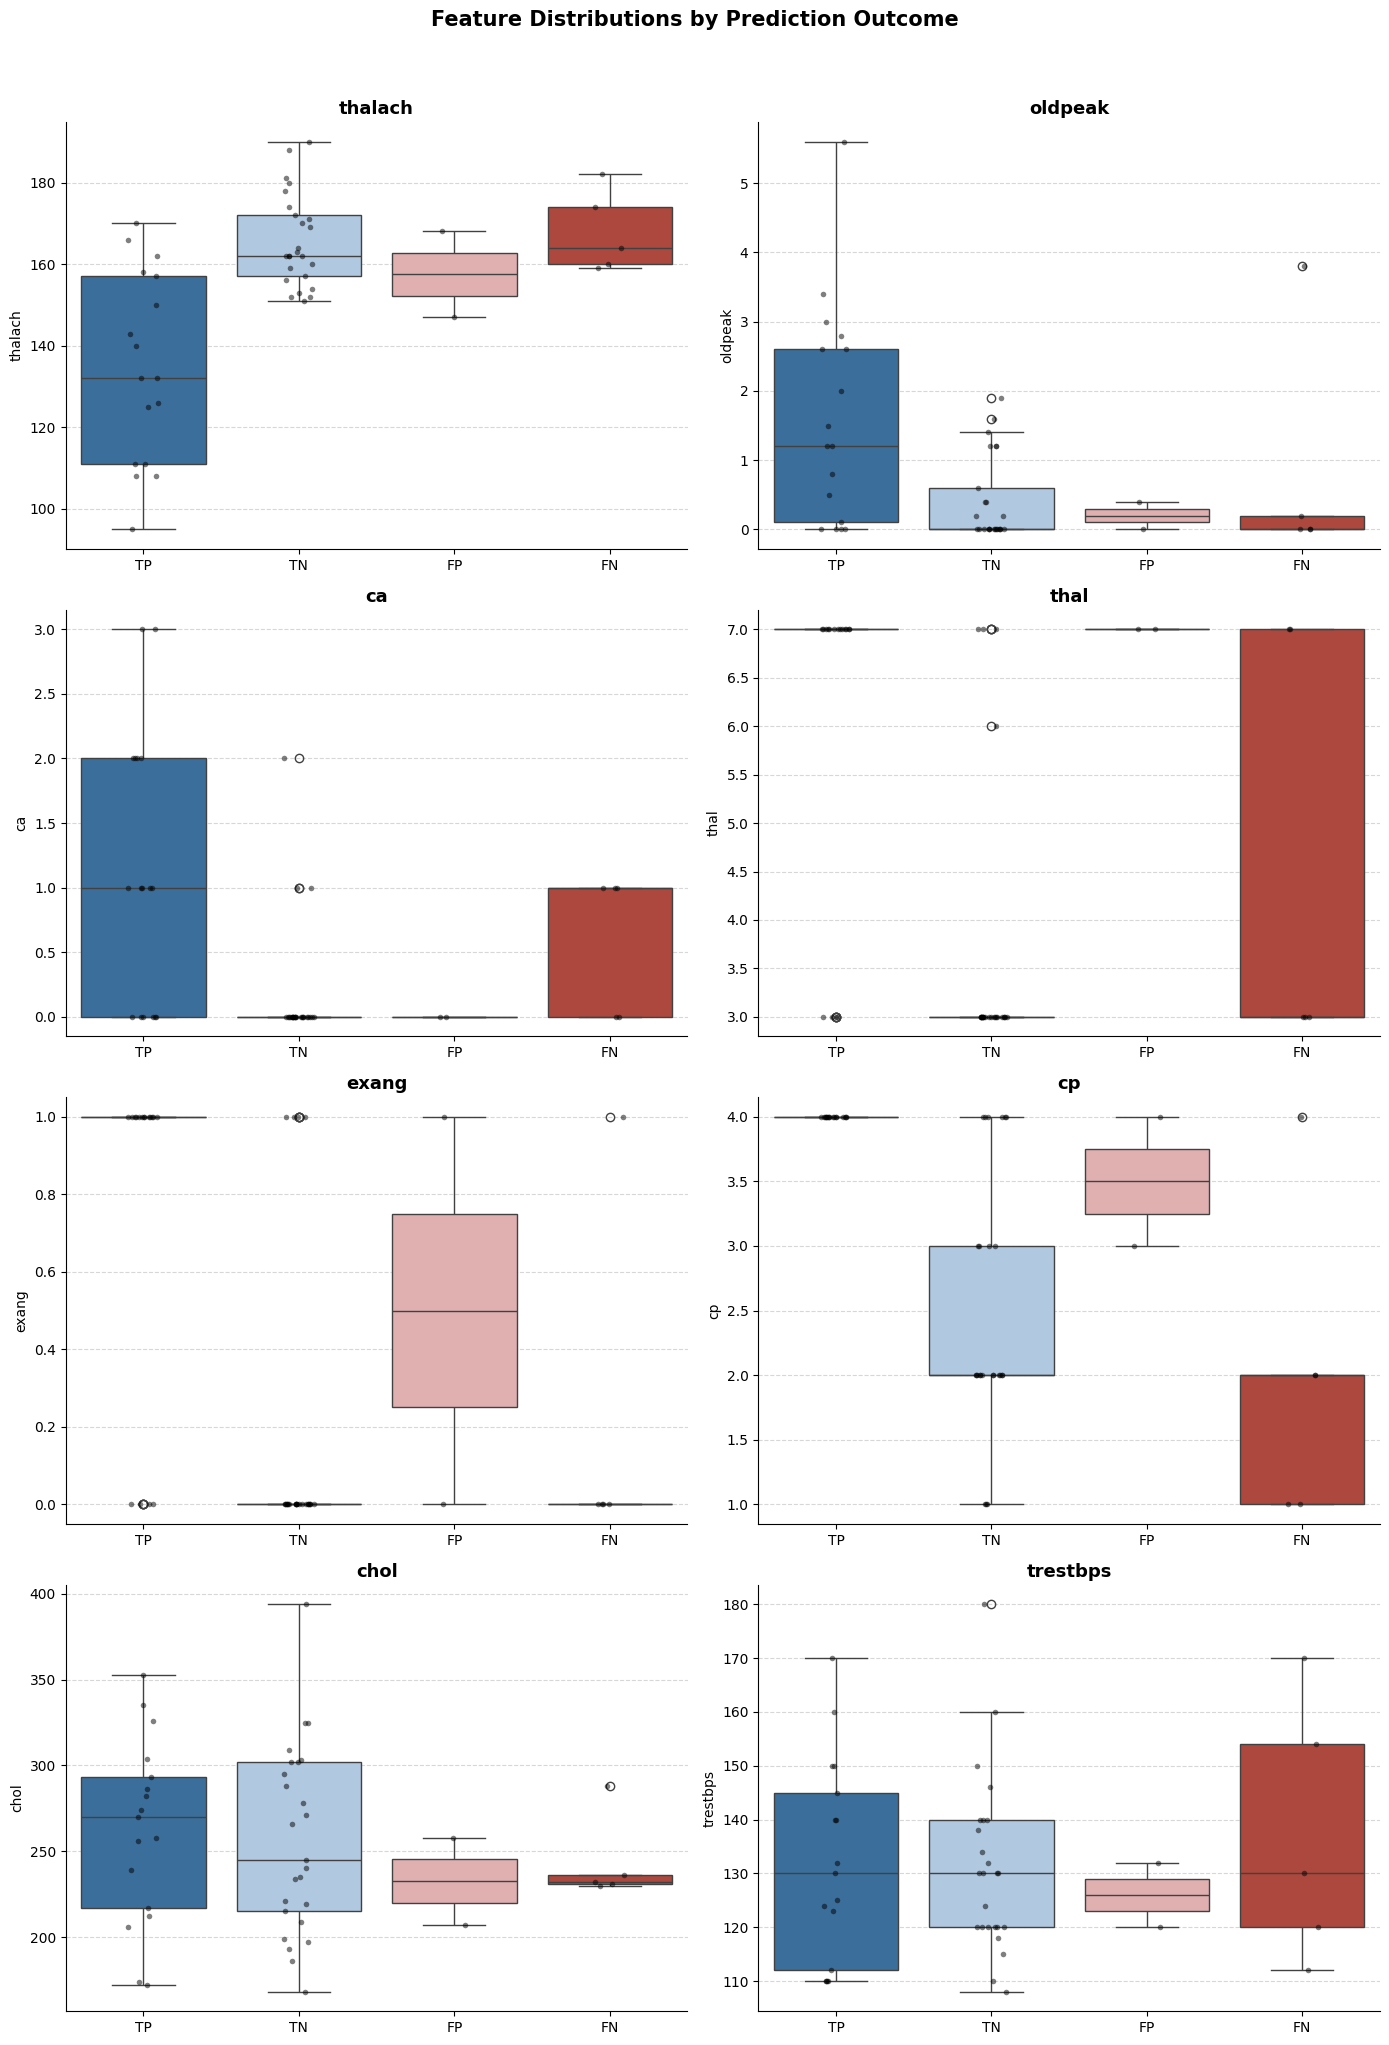


Feature summary by error type:
            thalach  oldpeak   ca  thal  exang   cp   chol  trestbps
error_type                                                          
FN            164.0      0.0  1.0   3.0    0.0  2.0  232.0     130.0
FP            157.5      0.2  0.0   7.0    0.5  3.5  232.5     126.0
TN            162.0      0.0  0.0   3.0    0.0  2.0  245.0     130.0
TP            132.0      1.2  1.0   7.0    1.0  4.0  270.0     130.0


In [13]:
# clinical features to compare
features_to_plot = ['thalach', 'oldpeak', 'ca', 'thal', 'exang', 'cp', 'chol', 'trestbps']

n_cols = 2
n_rows = (len(features_to_plot) + 1) // 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5*n_rows))
axes = axes.flatten()

order = ['TP', 'TN', 'FP', 'FN']
colors = {'TP': '#2C6FAC', 'TN': '#A8C8E8',
          'FN': '#C0392B', 'FP': '#E8A8A8'}

for i, feature in enumerate(features_to_plot):
    sns.boxplot(data=results_df, x='error_type', y=feature,
                order=order, palette=colors, ax=axes[i])
    sns.stripplot(data=results_df, x='error_type', y=feature,
                  order=order, color='black', size=4, 
                  alpha=0.5, ax=axes[i])
    axes[i].set_title(feature, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].spines[['top', 'right']].set_visible(False)
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Feature Distributions by Prediction Outcome', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/feature_comparison_error_types.png',
            dpi=300, bbox_inches='tight')
plt.show()

# summary statistics
print("\nFeature summary by error type:")
print(results_df.groupby('error_type')[features_to_plot].median().round(2))

### SHAP interpretations ###

In [14]:
# compute SHAP values on validation set
explainer = shap.LinearExplainer(model, X_train_proc)
shap_values_val = explainer.shap_values(X_val_proc)

# create SHAP explanation object
shap_explanation = shap.Explanation(
    values=shap_values_val,
    base_values=explainer.expected_value,
    data=X_val_proc,
    feature_names=X.columns.tolist()
)

print(f"SHAP values shape: {shap_values_val.shape}")

SHAP values shape: (49, 13)


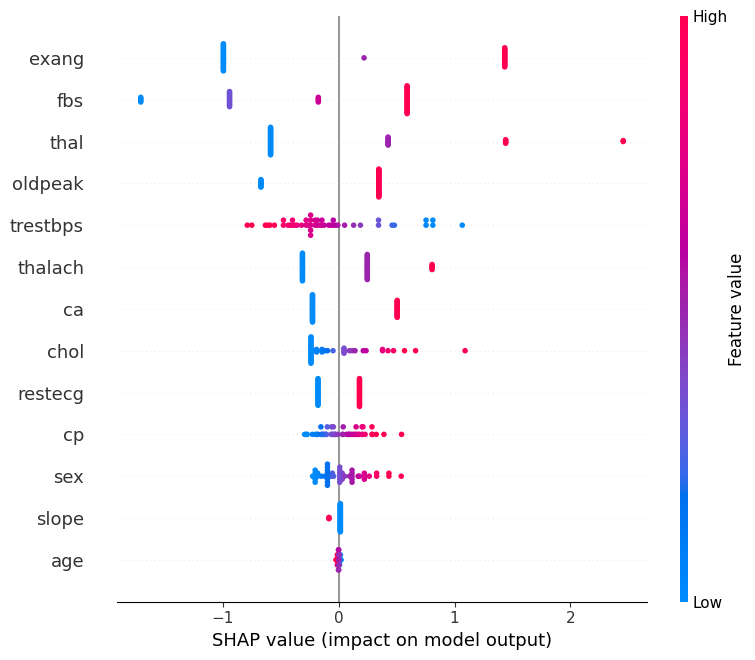

In [15]:
shap.summary_plot(
    shap_values_val,
    X_val_proc,
    feature_names=X.columns.tolist(),
    show=True,
    title='SHAP Values — Validation Set'
)

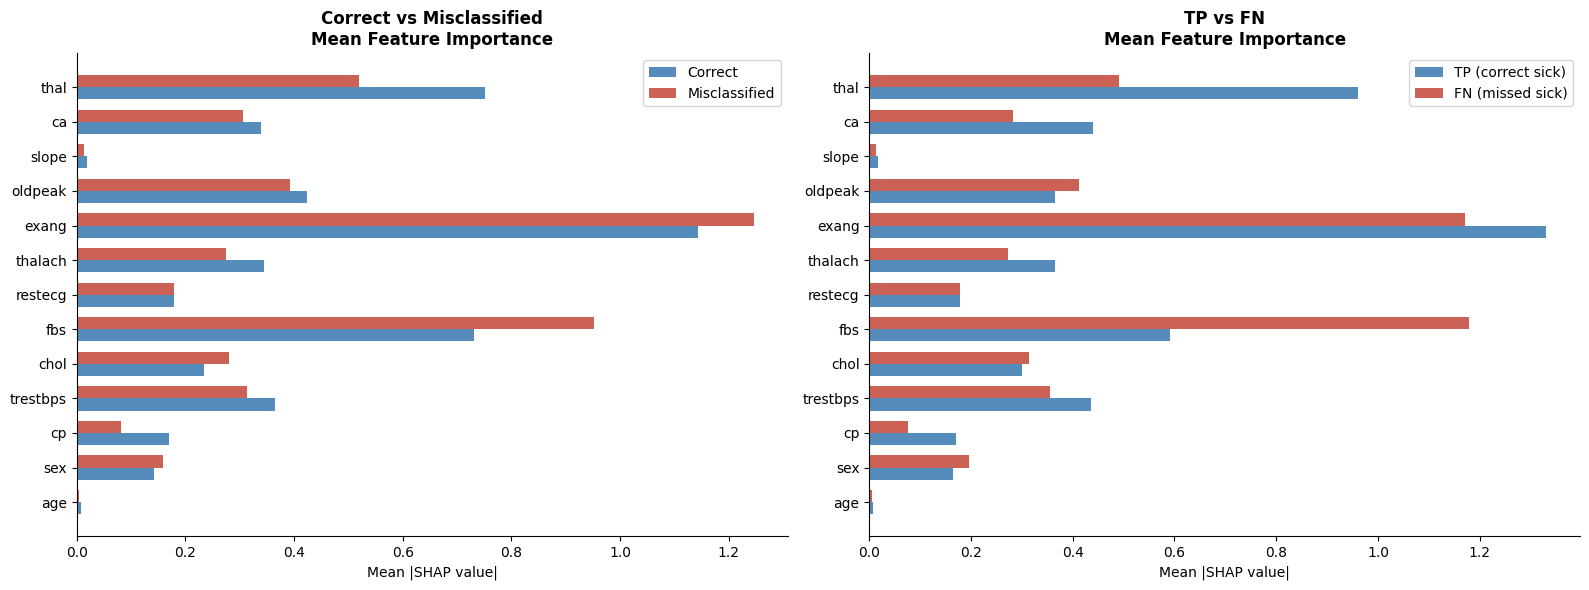

In [16]:
# split indices by error type
correct_idx = results_df[results_df['error_type'].isin(['TP', 'TN'])].index.tolist()
misclassified_idx = results_df[results_df['error_type'].isin(['FP', 'FN'])].index.tolist()
fn_idx = results_df[results_df['error_type'] == 'FN'].index.tolist()
fp_idx = results_df[results_df['error_type'] == 'FP'].index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# mean absolute SHAP — correct vs misclassified
mean_shap_correct = np.abs(shap_values_val[correct_idx]).mean(axis=0)
mean_shap_misclassified = np.abs(shap_values_val[misclassified_idx]).mean(axis=0)

feature_names = X.columns.tolist()
x = np.arange(len(feature_names))
width = 0.35

axes[0].barh(x - width/2, mean_shap_correct, width,
             label='Correct', color='#2C6FAC', alpha=0.8)
axes[0].barh(x + width/2, mean_shap_misclassified, width,
             label='Misclassified', color='#C0392B', alpha=0.8)
axes[0].set_yticks(x)
axes[0].set_yticklabels(feature_names)
axes[0].set_xlabel('Mean |SHAP value|')
axes[0].set_title('Correct vs Misclassified\nMean Feature Importance',
                  fontweight='bold')
axes[0].legend()
axes[0].spines[['top', 'right']].set_visible(False)

# mean absolute SHAP — FN specifically
mean_shap_fn = np.abs(shap_values_val[fn_idx]).mean(axis=0)
mean_shap_tp = np.abs(shap_values_val[
    results_df[results_df['error_type']=='TP'].index.tolist()
]).mean(axis=0)

axes[1].barh(x - width/2, mean_shap_tp, width,
             label='TP (correct sick)', color='#2C6FAC', alpha=0.8)
axes[1].barh(x + width/2, mean_shap_fn, width,
             label='FN (missed sick)', color='#C0392B', alpha=0.8)
axes[1].set_yticks(x)
axes[1].set_yticklabels(feature_names)
axes[1].set_xlabel('Mean |SHAP value|')
axes[1].set_title('TP vs FN\nMean Feature Importance',
                  fontweight='bold')
axes[1].legend()
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('../figures/shap_comparison_error_types.png',
            dpi=300, bbox_inches='tight')
plt.show()

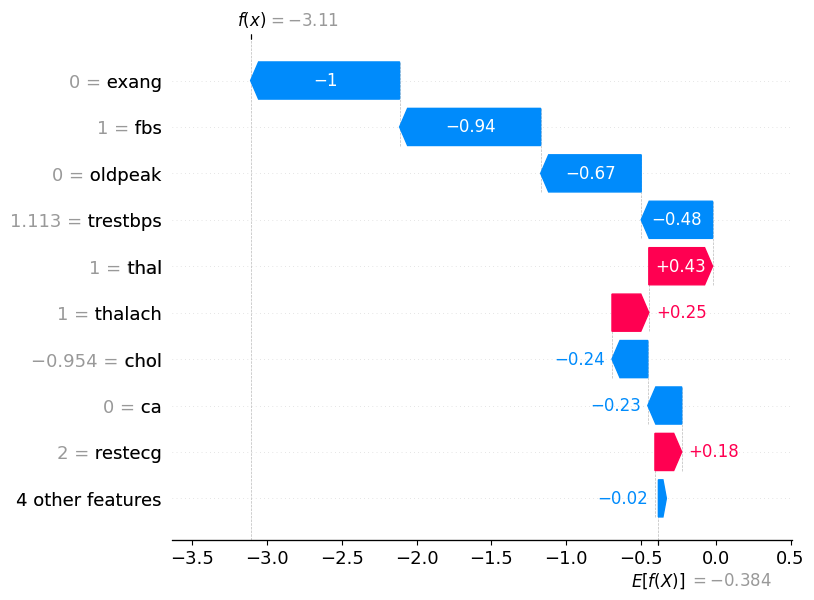

Patient 20 — True: 1 Predicted: 0 Probability: 0.043


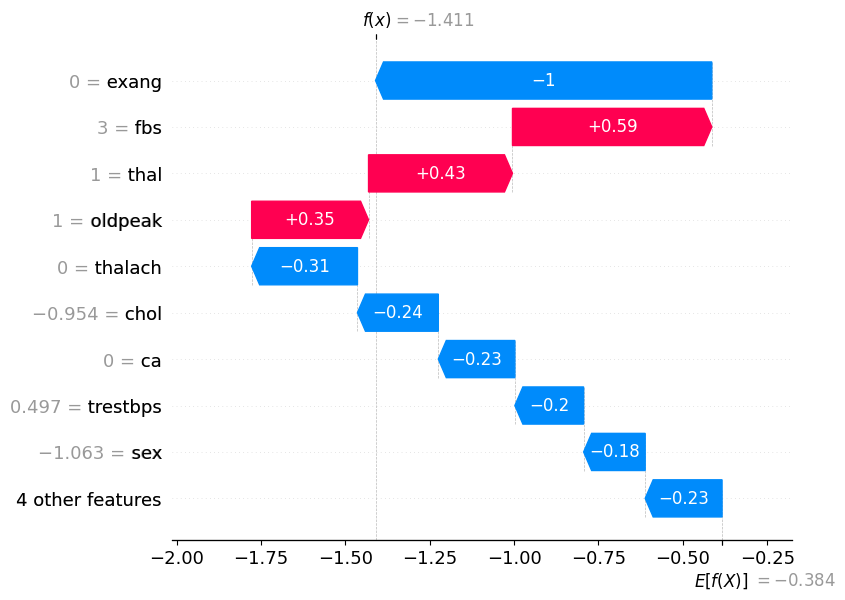

Patient 22 — True: 1 Predicted: 0 Probability: 0.196


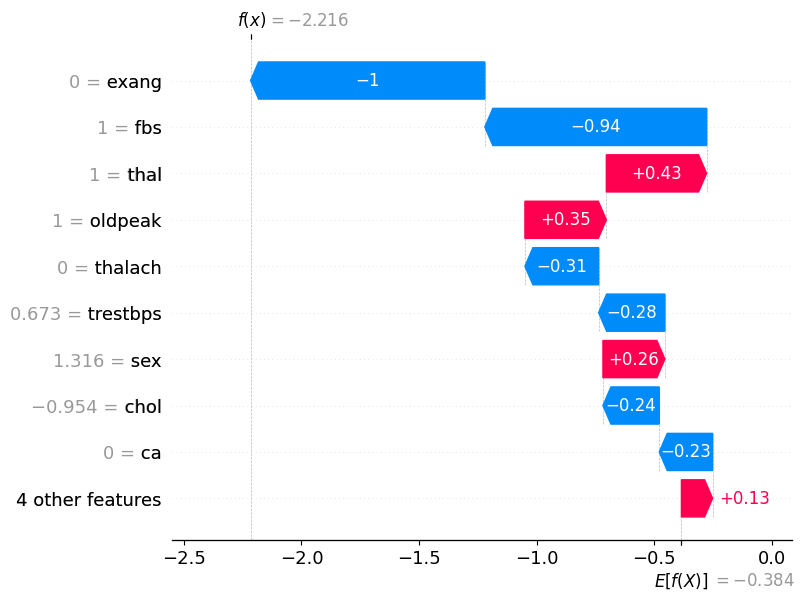

Patient 24 — True: 1 Predicted: 0 Probability: 0.098


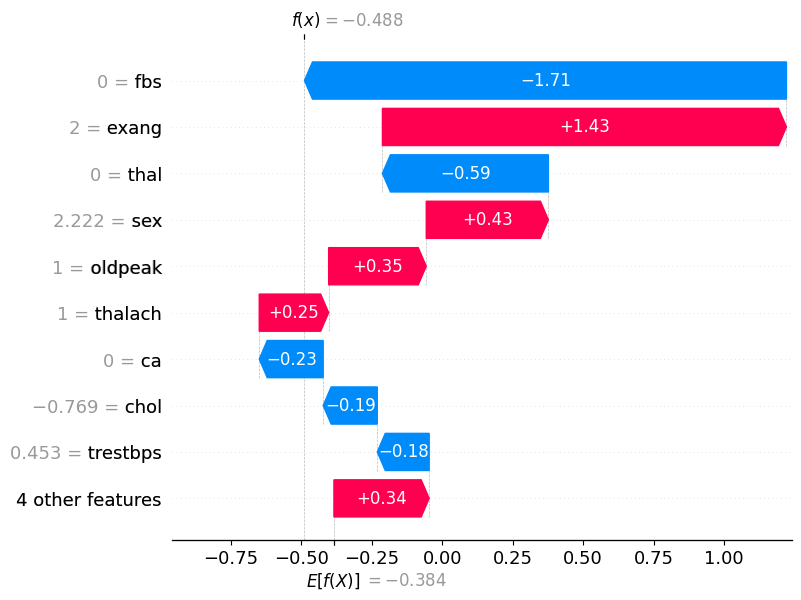

Patient 33 — True: 1 Predicted: 0 Probability: 0.380


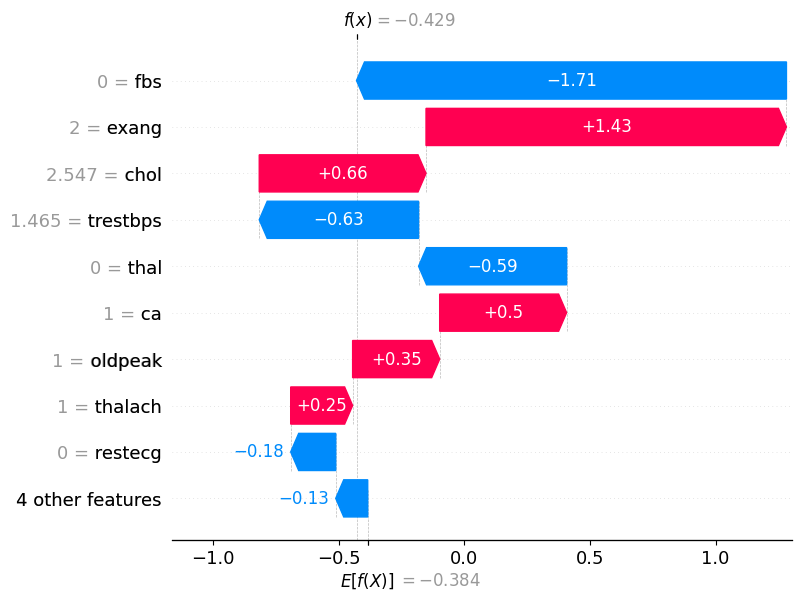

Patient 43 — True: 1 Predicted: 0 Probability: 0.394


In [17]:
# show individual SHAP explanations for each FN patient
for idx in fn_idx:
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values_val[idx],
            base_values=explainer.expected_value,
            data=X_val_proc[idx],
            feature_names=X.columns.tolist()
        )
    )
    print(f"Patient {idx} — True: {results_df.loc[idx, 'true']} "
          f"Predicted: {results_df.loc[idx, 'predicted']} "
          f"Probability: {results_df.loc[idx, 'probability']:.3f}")